Iteration 0: Cost = 22.16, w = 0.2500, b = 0.0700
Iteration 100: Cost = 0.01, w = 2.0967, b = 0.6508
Iteration 200: Cost = 0.01, w = 2.0817, b = 0.7052
Iteration 300: Cost = 0.01, w = 2.0690, b = 0.7511
Iteration 400: Cost = 0.00, w = 2.0582, b = 0.7898
Iteration 500: Cost = 0.00, w = 2.0492, b = 0.8225
Iteration 600: Cost = 0.00, w = 2.0415, b = 0.8502
Iteration 700: Cost = 0.00, w = 2.0350, b = 0.8735
Iteration 800: Cost = 0.00, w = 2.0296, b = 0.8932
Iteration 900: Cost = 0.00, w = 2.0250, b = 0.9098
w:2.0211314863929593 , b:0.9237086291370951


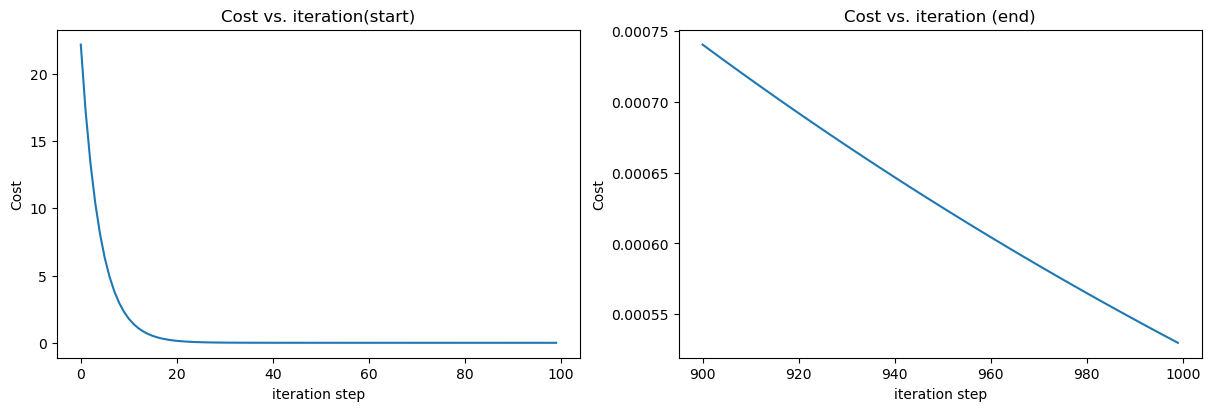

My Prediction 13.050497547494851


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

def compute_cost(x,y,w,b):
    m = x.shape[0]
    sum_cost=0
    for i in range(m):
        f_wb = w*x[i]+b
        cost = (f_wb-y[i])**2
        sum_cost+=cost
    total_cost = (1/(2*m))*sum_cost
    return total_cost

def compute_gradient(x,y,w,b):
    m = x.shape[0]
    g_w=0
    g_b=0
    for i in range(m):
        f_wb = w*x[i]+b
        g_w_i = (f_wb-y[i])*x[i]
        g_b_i = (f_wb-y[i])
        g_w+=g_w_i
        g_b+=g_b_i
    gradient_w=(1/m)*g_w
    gradient_b=(1/m)*g_b
    return gradient_w ,gradient_b

def gradient_descent(x, y, w, b, alpha, iterations):
    history = [] 
    for i in range(iterations):
        gradient_w,gradient_b= compute_gradient(x, y, w, b)
        w = w - alpha * gradient_w
        b = b - alpha * gradient_b
        cost = compute_cost(x, y, w, b)
        if i % 100 == 0:  # print cost every 100 iterations
            print(f"Iteration {i}: Cost = {cost:.2f}, w = {w:.4f}, b = {b:.4f}")
        history.append(cost)
    return w, b , history

x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])
#greater dataset means u need smaller learning rate

w = 0
b = 0
alpha = 0.01
iterations = 1000

new_w , new_b , history = gradient_descent(x,y,w,b,alpha,iterations)
print(f'w:{new_w} , b:{new_b}')

# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(history[:100])
ax2.plot(900 + np.arange(len(history[900:])), history[900:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()


#making prediction
print(f"My Prediction {new_w*6 + new_b}")